# **Children Gait: Qwen2.5-VL Analyse Motions**
## **Solution Version for multiple motions using for-loop**
Children Gait: Qwen2.5-VL Final

In [1]:
!pip install -U bitsandbytes>=0.46.1

!pip install -U yt-dlp
!apt-get update && apt-get install -y ffmpeg

!pip install --upgrade transformers
!pip install -q accelerate pillow torch qwen-vl-utils

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 49.8 MB/s eta 0:00:00
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,533 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubunt

In [2]:
import glob
import json
import os
import re
import io
import shutil
import subprocess
import sys
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
from PIL import Image
from qwen_vl_utils import process_vision_info
from transformers import (
    AutoProcessor,
    BitsAndBytesConfig,
    Qwen2_5_VLForConditionalGeneration,
)


In [3]:
import glob
import os

json_dir = "/kaggle/input/datasets/stpeteishii/cvpr-2026-children-gait-data/dataset"

patterns = [
    os.path.join(json_dir, "*/*/")
]

dirs = []
for p in patterns:
    dirs.extend(glob.glob(p))

dir_list = [os.path.normpath(d) for d in dirs]
print(len(dir_list))

1185


In [4]:
"""
The images above are frames extracted at fixed intervals from the same video.
ALL frames holistically in a SINGLE inference call using Qwen2.5-VL.
Each question is answered ONCE per video, not per frame.
"""

# =============================================================
# Settings
# =============================================================
MODEL_ID    = "Qwen/Qwen2.5-VL-7B-Instruct"
OUTPUT_DIR  = "frames"
RESULT_JSON = "results.json"

# Max frames to send in one inference (memory guard)
MAX_FRAMES = 10

In [5]:
import cv2

def draw_one_instance(canvas, instance, score_thr=0.2, kp_radius=4, line_thickness=3):
    """
    Standard drawing function for the Children Gait dataset.
    Renders keypoints and skeletons based on the instance_info in the JSON.
    """
    keypoints = instance.get('keypoints', [])
    scores = instance.get('keypoint_scores', [])
    
    # Define skeleton connections (edges)
    # Note: These indices vary by dataset, but for this competition 
    # it typically follows the COCO-Wholebody or similar format.
    # The organizer's script usually provides the specific 'skeleton' list.
    skeleton = [
        (15, 13), (13, 11), (16, 14), (14, 12), (11, 12), (5, 11), (6, 12), (5, 6),
        (5, 7), (6, 8), (7, 9), (8, 10), (1, 2), (0, 1), (0, 2), (1, 3), (2, 4), (3, 5), (4, 6)
    ]

    # Draw lines (bones)
    for sk in skeleton:
        pos1 = (int(keypoints[sk[0]][0]), int(keypoints[sk[0]][1]))
        pos2 = (int(keypoints[sk[1]][0]), int(keypoints[sk[1]][1]))
        if scores[sk[0]] > score_thr and scores[sk[1]] > score_thr:
            cv2.line(canvas, pos1, pos2, (0, 255, 0), line_thickness)

    # Draw points (joints)
    for i, (kp, score) in enumerate(zip(keypoints, scores)):
        if score > score_thr:
            pos = (int(kp[0]), int(kp[1]))
            cv2.circle(canvas, pos, kp_radius, (0, 0, 255), -1)

In [6]:
# =============================================================
# Step 1: Generate Skeleton Images from JSON
# =============================================================
import os
import json
import cv2
import numpy as np
import shutil
from pathlib import Path


def extract_frames_from_json(json_dir: str, output_dir: str, max_frames: int = 8) -> list[str]:
    json_path = Path(json_dir)
    json_files = sorted(json_path.glob("frame_*.json"))
    
    if not json_files:
        raise FileNotFoundError(f"No JSON files found in {json_dir}")

    # --- Logic: Capture frames from the middle with a stride of 4 ---
    total = len(json_files)
    mid = 2
    selected_files = json_files[mid : mid + max_frames * 20:20] ####
    print(selected_files)

    print(f"Total frames: {total}, Mid index: {mid}")

    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(output_dir, exist_ok=True)

    frame_paths = []
    for i, j_file in enumerate(selected_files):
        with open(j_file, 'r') as f:
            data = json.load(f)
        
        vi = data.get('video_info', {})
        w, h = vi.get('width', 1920), vi.get('height', 1080)
        canvas = np.zeros((h, w, 3), dtype=np.uint8)

        for inst in data.get("instance_info", []):
            draw_one_instance(canvas, inst, score_thr=0.2, kp_radius=4, line_thickness=3)
        
        save_path = os.path.join(output_dir, f"frame_{i:04d}.jpg")
        cv2.imwrite(save_path, canvas)
        frame_paths.append(save_path)
    
    return frame_paths

In [7]:
# =============================================================
# Step 2: Load model
# =============================================================
def load_model(model_id: str):
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
    )
    gpu_count = torch.cuda.device_count()
    print(f"  Device: {'GPU x' + str(gpu_count) if gpu_count else 'CPU'}")

    processor = AutoProcessor.from_pretrained(
        model_id,
        min_pixels=256 * 28 * 28,
        max_pixels=512 * 28 * 28,
        trust_remote_code=True,
    )
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
    )
    model.eval()
    return model, processor


# =============================================================
# Step 3: Single holistic inference over ALL frames
# =============================================================
def _infer(model, processor, messages: list) -> str:
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        return_tensors="pt",
    )
    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=512)
    generated = output_ids[:, inputs["input_ids"].shape[1]:]
    return processor.batch_decode(
        generated,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]


def analyze_video(
    model,
    processor,
    frame_paths: list[str],
    prompts: list[str],
    max_frames: int = MAX_FRAMES,
) -> dict:
    """
    Generate a GIF from frame_paths and analyze it as a continuous motion sequence.
    """
    # --- Sub-sample if too many frames ---
    if len(frame_paths) > max_frames:
        step = len(frame_paths) / max_frames
        frame_paths = [frame_paths[int(i * step)] for i in range(max_frames)]
        print(f"  Sub-sampled to {len(frame_paths)} frames (max_frames={max_frames})")

    print(f"  Creating animation from {len(frame_paths)} frames...")
    images = [Image.open(p).convert("RGB") for p in frame_paths]

    # --- Create GIF in memory ---
    gif_buf = io.BytesIO()
    # duration in ms (100ms = approx 10fps, suitable for gait observation)
    images[0].save(
        gif_buf,
        format="GIF",
        save_all=True,
        append_images=images[1:],
        duration=100,
        loop=0
    )
    gif_buf.seek(0)
    
    # Final GIF object (write to temp file if the model requires a path instead of an object)
    animated_gif = Image.open(gif_buf)

    # --- Build question block ---
    # Refined prompt assuming motion is present
    question_block = (
        "You are an expert video analyst. "
        f"The {len(images)} provided images are sequential frames from a single dashcam video, "
        "ordered chronologically from start to finish.\n\n"
        
        "### TASK ###\n"
        "1. Analyze all frames as a continuous temporal sequence.\n"
        "2. Tracking objects and environment changes across the entire timeline.\n"
        "3. Answer EACH question based on the collective information from ALL frames.\n\n"
        
        "### OUTPUT FORMAT ###\n"
        "Return ONLY a raw JSON object. Do not include markdown code blocks (```json ... ```), "
        "introductory text, or explanations. Use the exact question strings provided below as keys.\n"
        "Example: {\"Question Text 1\": 0, \"Question Text 2\": 1}\n\n"
        
        "### QUESTIONS ###\n"
        + "\n".join(f"- {p}" for p in prompts)
    )

    # --- Build Message (Send GIF as a single vision entity) ---
    # Depending on model specs, "type" could be "video" or "image".
    # Many VLMs interpret multi-frame GIFs under the "image" type as animation.
    content = [
        {"type": "image", "image": animated_gif}, 
        {"type": "text", "text": question_block}
    ]

    messages = [{"role": "user", "content": content}]

    print("  Running single holistic inference on animated GIF...")
    raw_output = _infer(model, processor, messages)
    print(f"  Raw output:\n{raw_output}\n")

    # --- Parse JSON from response ---
    answers = _parse_json(raw_output, prompts)
    return answers


def _parse_json(raw: str, prompts: list[str]) -> dict:
    """
    Extract the JSON object from the model output.
    Falls back to -1 (Unknown) for any missing keys.
    """
    # Extract question keys from prompt strings e.g. "Q1.a", "Q5"
    keys = [re.match(r"(Q[\d]+\.[a-z]|Q[\d]+)", p).group(1) for p in prompts]

    # Try to find a JSON block in the output
    json_match = re.search(r"\{.*\}", raw, re.DOTALL)
    if json_match:
        try:
            parsed = json.loads(json_match.group())
            # Ensure all keys are present; fill missing with -1
            return {k: int(parsed.get(k, -1)) for k in keys}
        except json.JSONDecodeError:
            pass

    # If JSON parsing fails, return all -1
    print("  WARNING: Could not parse JSON from model output. Filling with -1.")
    return {k: -1 for k in keys}



In [8]:
print("Loading model...")
model, processor = load_model(MODEL_ID)

Loading model...
  Device: GPU x2


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

In [9]:
# =============================================================
# Step 2: Gait Analysis Prompts Final Version
# =============================================================
GAIT_PROMPTS = [
    'Q1: Is the gait pattern symmetric? (0: Symmetric, 1: Asymmetric, -1: Unknown)',
    'Q2: What is the primary gait characteristic? (0: Normal, 1: Limping, 2: Short steps, 3: Toe-walking, -1: Unknown)',
    'Q3: Does the child maintain a stable trunk posture? (0: Stable, 1: Unstable/Leaning, -1: Unknown)'
]

In [10]:
print("Loading model...")
model, processor = load_model(MODEL_ID)

Loading model...
  Device: GPU x2


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

# **Analyse**

In [11]:
import gc
import time

# =============================================================
# Step 3: Execution Logic
# =============================================================
# (Assume the model and processor are loaded via load_model(MODEL_ID))

# Example target directory
for i in range(1,2): #len(dir_list)
    gait_dir = dir_list[i]
    print(gait_dir)
    
    # 1. Generate skeleton images from the raw JSON data
    print("[1] Generating skeleton images from JSON...")
    frame_paths = extract_frames_from_json(gait_dir, OUTPUT_DIR, max_frames=MAX_FRAMES)
    print(frame_paths)
    
    # 2. Run VQA Inference
    print("[2] Analyzing skeleton sequence with Qwen2.5-VL...")
    # Call the existing analyze_video function using the new GAIT_PROMPTS
    answers = analyze_video(model, processor, frame_paths, GAIT_PROMPTS)
    
    print("=== Result ===")
    print(json.dumps(answers, indent=2))
    
    result = {
        "id": gait_dir.split('/')[-1],
        "answers": answers,
    }
    
    with open("results.jsonl", "a", encoding="utf-8") as f:
        f.write(json.dumps(result, ensure_ascii=False) + "\n")

    gc.collect()
    time.sleep(1)

/kaggle/input/datasets/stpeteishii/cvpr-2026-children-gait-data/dataset/0105/0105-0003_backward_1071-1905_filtered_pose
[1] Generating skeleton images from JSON...
[PosixPath('/kaggle/input/datasets/stpeteishii/cvpr-2026-children-gait-data/dataset/0105/0105-0003_backward_1071-1905_filtered_pose/frame_00000002.json'), PosixPath('/kaggle/input/datasets/stpeteishii/cvpr-2026-children-gait-data/dataset/0105/0105-0003_backward_1071-1905_filtered_pose/frame_00000022.json'), PosixPath('/kaggle/input/datasets/stpeteishii/cvpr-2026-children-gait-data/dataset/0105/0105-0003_backward_1071-1905_filtered_pose/frame_00000042.json'), PosixPath('/kaggle/input/datasets/stpeteishii/cvpr-2026-children-gait-data/dataset/0105/0105-0003_backward_1071-1905_filtered_pose/frame_00000062.json'), PosixPath('/kaggle/input/datasets/stpeteishii/cvpr-2026-children-gait-data/dataset/0105/0105-0003_backward_1071-1905_filtered_pose/frame_00000082.json'), PosixPath('/kaggle/input/datasets/stpeteishii/cvpr-2026-children-

In [12]:
rows_list = []
with open("results.jsonl", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        data = json.loads(line)
        frame_id = data['id']
        answers = list(data['answers'].values())
        row = [frame_id] + answers
        rows_list.append(row)
        
columns=['id']+GAIT_PROMPTS
submit = pd.DataFrame(rows_list, columns=columns)
submit2=submit.drop_duplicates(subset='id')
submit2.to_csv('submission.csv', index=False)

In [13]:
!pip install imageio

In [14]:
import os
import imageio.v2 as imageio

input_folder = 'frames'
output_file = 'animation.gif'
fps = 10  

files = sorted([f for f in os.listdir(input_folder) if f.endswith(('.png', '.jpg'))])

images = []
for filename in files:
    images.append(imageio.imread(os.path.join(input_folder, filename)))

imageio.mimsave(output_file, images, fps=fps, loop=0)

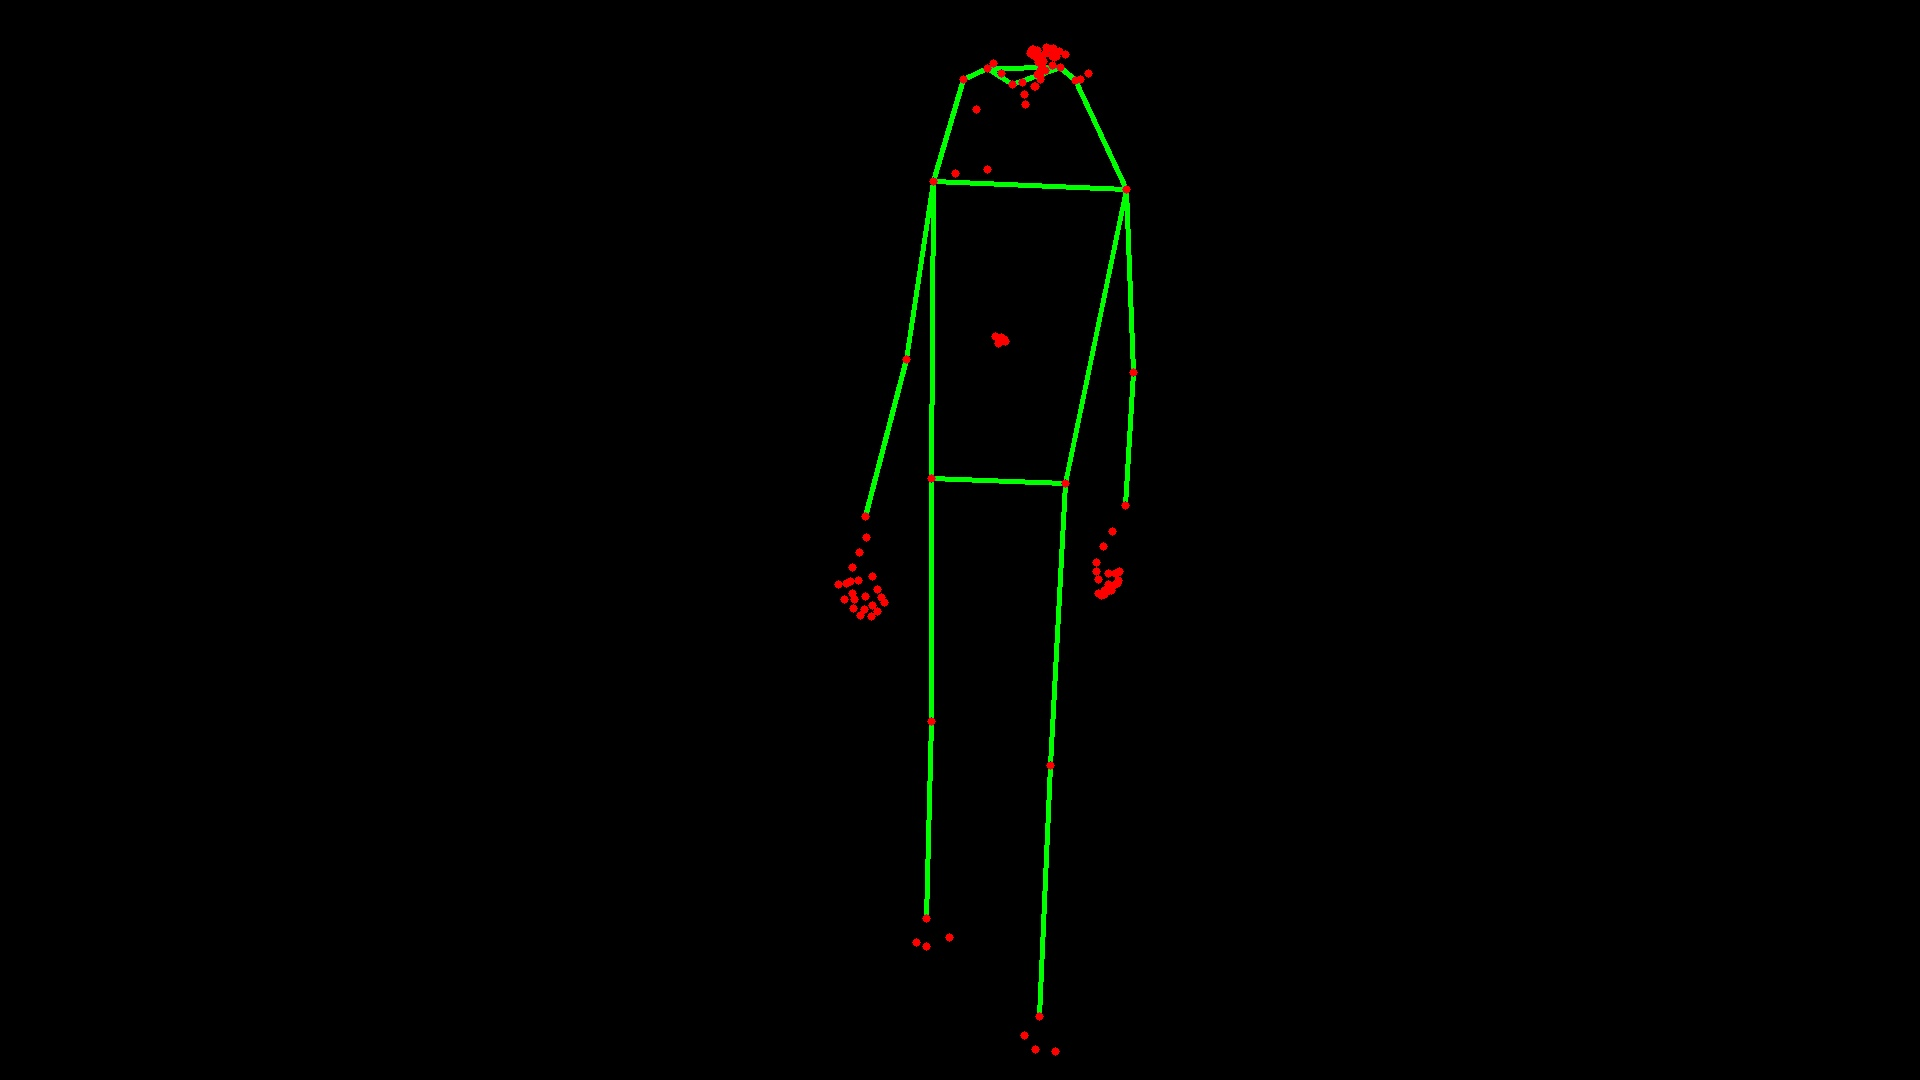

In [15]:
from IPython.display import Image
Image(open(output_file, 'rb').read())